# HomeCast Valuation Model — Training, Evaluation, and Honesty Checks

This notebook trains the valuation model behind HomeCast's Gurgaon price
estimates and evaluates it the way it needs to be evaluated before anyone
should trust its output: with cross-validation that never lets a listing's
own price leak into the features used to predict it, and benchmarked against
the two pricing rules a buyer or agent would fall back on without a model at
all — a sector's median price per square foot, and the city's median price
per square foot.

Every number below comes from calling the `homecast` package directly — the
cleaning pipeline, the feature builder, the model, and the plotting style are
all imported from `src/homecast`, not redefined here. That's deliberate: this
notebook is a report on the shipped pipeline, not a separate implementation
of it.

We cover, in order: why the model is trained to predict *log* price rather
than price; the feature set, including the one feature that needs care
(a sector-level target encoding, and why computing it on the full dataset
before splitting into folds would quietly leak the answer); the
cross-validation design; the results table against both baselines; the
residual distribution and the uncertainty band it produces; which features
the trained model actually leans on; how error varies by price band; and,
finally, an honest account of what the model doesn't know.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent / "src"))  # make `homecast` importable when run from notebooks/

from homecast.cities import get_city
from homecast.cleaning import clean_city
from homecast.features import FEATURE_COLUMNS, sector_encoding, build_features, target
from homecast.model import DEFAULT_PARAMS, evaluate, train_final, predict_price
from homecast.valuation import Query, estimate
from homecast.plotting import PALETTE, SERIES, BLUES, apply_plot_style, save_figure

apply_plot_style()
pd.set_option("display.max_columns", 30)

city = get_city("gurgaon")

## Data

`clean_city` runs the same cleaning pipeline the EDA notebook walks through
step by step: standardize column names, drop exact duplicates, label the
categorical columns, drop listings with no price, and trim the extreme 0.5%
tails of price-per-sqft and area (the data-entry errors, not the genuine
luxury tail). Calling it here — rather than reading a pre-cleaned CSV —
means this notebook reruns the real pipeline from the raw feed every time,
so the row counts below are proof of reproducibility, not a copy-pasted
number.

In [2]:
df, log = clean_city("gurgaon")
for line in log:
    print(" -", line)
print(f"\nCleaned dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")
assert df.shape[0] == 3600, "row count drifted from the documented cleaning run"
df.head()

 - standardize column names: ok
 - drop exact duplicate listings: 126 rows removed (3677 remain)
 - label categorical columns: ok
 - drop listings without a price: 17 rows removed (3660 remain)
 - trim percentile outliers (price_per_sqft, area): 60 rows removed (3600 remain)

Cleaned dataset: 3,600 rows x 23 columns


,property_type,society,sector,price,price_per_sqft,area,area_with_type,bedrooms,bathrooms,balcony,floor_num,facing,age_possession,super_built_up_area,built_up_area,carpet_area,has_study_room,has_servant_room,has_store_room,has_pooja_room,has_other_rooms,furnishing_type,luxury_score
0,flat,signature global park 4,sector 36,0.82,7585.0,1081.0,Super Built up area 1081(100.43 sq.m.)Carpet a...,3,2,2,2.0,NaN,New Property,1081.0,NaN,650.0,0,0,0,0,0,unfurnished,8
1,flat,smart world gems,sector 89,0.95,8600.0,1105.0,Carpet area: 1103 (102.47 sq.m.),2,2,2,4.0,NaN,New Property,NaN,NaN,1103.0,1,1,0,0,0,unfurnished,38
2,flat,breez global hill view,sohna road,0.32,5470.0,585.0,Built Up area: 1000 (92.9 sq.m.)Carpet area: 5...,2,2,1,17.0,NaN,New Property,NaN,1000.0,585.0,0,0,0,0,0,unfurnished,49
3,flat,bestech park view sanskruti,sector 92,1.60,8020.0,1995.0,Super Built up area 1995(185.34 sq.m.)Built Up...,3,4,3+,10.0,North-West,Relatively New,1995.0,1615.0,1476.0,0,1,0,0,1,semi-furnished,174
4,flat,suncity avenue,sector 102,0.48,9022.0,532.0,Super Built up area 632(58.71 sq.m.)Carpet are...,2,2,1,5.0,North-East,Relatively New,632.0,NaN,532.0,0,0,1,0,0,unfurnished,159


## Why the model predicts log(price), not price

Gurgaon listing prices are heavily right-skewed: the median listing is
1.54 Cr but the mean is pulled up to 2.51 Cr by a long tail of luxury
properties running as high as 31.5 Cr. `GradientBoostingRegressor` minimizes
squared error by default, and squared error on raw rupee prices would let
that tail dominate the loss — the model would spend its capacity getting the
handful of multi-crore listings a little less wrong, at the expense of the
thousands of ordinary flats that make up most of the market.

Training on `log(price)` instead reframes the loss in relative terms. A
Rs 10 lakh miss on a 50 lakh flat and a Rs 10 lakh miss on a 5 Cr house are
wildly different mistakes in rupee space, but a 20% miss is a 20% miss in log
space regardless of price level — which is also how a buyer actually judges
a valuation ("that's about right" vs. "that's way off"), and how the model
is scored here (MAPE). Predictions are converted back with `exp()` before
they're compared to anything in rupees; `homecast.model.predict_price` and
`evaluate` both do this conversion internally, so nothing downstream ever
sees a log value by accident.

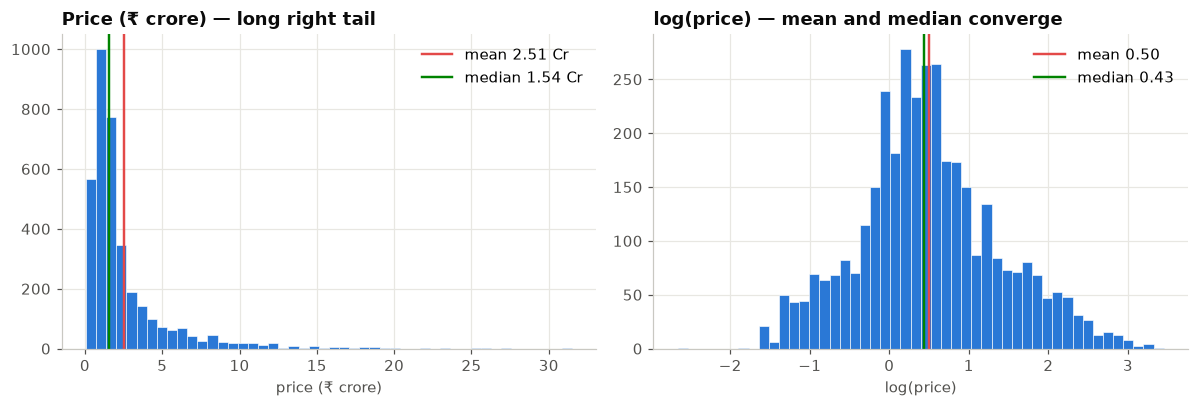

median 1.54 Cr | mean 2.51 Cr | p25 0.95 | p75 2.70 | max 31.50 Cr
skew(price)     = 3.31
skew(log price) = 0.28


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

axes[0].hist(df["price"], bins=48, color=PALETTE["blue"], edgecolor="white", linewidth=0.4)
axes[0].axvline(df["price"].mean(), color=PALETTE["red"], linewidth=1.6,
                label=f"mean {df['price'].mean():.2f} Cr")
axes[0].axvline(df["price"].median(), color=PALETTE["green"], linewidth=1.6,
                label=f"median {df['price'].median():.2f} Cr")
axes[0].set_title("Price (₹ crore) — long right tail")
axes[0].set_xlabel("price (₹ crore)")
axes[0].legend()

log_price = np.log(df["price"])
axes[1].hist(log_price, bins=48, color=PALETTE["blue"], edgecolor="white", linewidth=0.4)
axes[1].axvline(log_price.mean(), color=PALETTE["red"], linewidth=1.6,
                label=f"mean {log_price.mean():.2f}")
axes[1].axvline(log_price.median(), color=PALETTE["green"], linewidth=1.6,
                label=f"median {log_price.median():.2f}")
axes[1].set_title("log(price) — mean and median converge")
axes[1].set_xlabel("log(price)")
axes[1].legend()

fig.tight_layout()
save_figure(fig, "price_log_transform")
plt.show()

print(f"median {df['price'].median():.2f} Cr | mean {df['price'].mean():.2f} Cr | "
      f"p25 {df['price'].quantile(.25):.2f} | p75 {df['price'].quantile(.75):.2f} | max {df['price'].max():.2f} Cr")
print(f"skew(price)     = {df['price'].skew():.2f}")
print(f"skew(log price) = {log_price.skew():.2f}")

## Features, and the one that needs care

The model sees eight features, listed in `homecast.features.FEATURE_COLUMNS`:

| Feature | What it captures |
|---|---|
| `area` | Built-up area in sq. ft. — the strongest single lever on price. |
| `bedrooms` | Bedroom (BHK) count. |
| `bathrooms` | Bathroom count. |
| `is_house` | 1 for an independent house, 0 for a flat/apartment. |
| `furnishing_code` | Ordinal 0/1/2 for unfurnished / semi-furnished / furnished. |
| `luxury_score` | A 0–100 composite amenity score already present in the listing (finishes, clubhouse, security, and similar). |
| `age_code` | Ordinal 0–4 for possession status, from under-construction to old property; unlabeled listings fall back to -1. |
| `sector_ppsf` | The sector's median price per sq. ft. — the model's only location signal, since the dataset has no latitude/longitude. |

Seven of those columns are read straight off a listing. `sector_ppsf` is
different: it's a target encoding, built by `homecast.features.sector_encoding`
as the median `price_per_sqft` of the *training* rows in each sector, with a
global-median fallback for any sector not seen in training.

That distinction — training rows only — is the whole point. `price_per_sqft`
is derived directly from `price`, the value we're trying to predict. If the
sector medians were computed once over the *entire* dataset before splitting
into folds, every held-out row's own price would have contributed to the
very feature used to predict it. The model would partly be predicting a
number computed from itself, cross-validation would report an inflated R²
and a deflated MAE/MAPE, and none of that improvement would survive contact
with a genuinely new listing. `evaluate` avoids this by calling
`sector_encoding(train)` freshly inside every fold, using only that fold's
training rows, and rebuilding the test-fold features from that fold-local
map. The source below is the actual function that runs the cross-validation
in this notebook — not a re-implementation of it.

In [4]:
import inspect
print(inspect.getsource(evaluate))

def evaluate(df: pd.DataFrame, params: dict = DEFAULT_PARAMS, n_splits: int = 5) -> dict:
    df = df.reset_index(drop=True)
    _validate_prices(df)
    oof = {k: np.zeros(len(df)) for k in ("model", "baseline_sector", "baseline_global")}
    for tr_idx, te_idx in KFold(n_splits, shuffle=True, random_state=7).split(df):
        tr, te = df.iloc[tr_idx], df.iloc[te_idx]
        smap = sector_encoding(tr)                      # fold-local: no leakage
        est = GradientBoostingRegressor(**params)
        est.fit(build_features(tr, smap), target(tr))
        oof["model"][te_idx] = np.exp(est.predict(build_features(te, smap)))
        oof["baseline_sector"][te_idx] = _baseline_pred(tr, te, by_sector=True)
        oof["baseline_global"][te_idx] = _baseline_pred(tr, te, by_sector=False)
    actual = df["price"].to_numpy(dtype=float)
    out = {k: _metrics(actual, v) for k, v in oof.items()}
    out["residuals_log"] = (np.log(oof["model"]) - np.log(actual)).tolist()
    out["n"] = len(df)

## Cross-validation design

`evaluate` runs 5-fold `KFold` (shuffled, `random_state=7`) over the 3,600
cleaned listings. Within each fold it fits the sector encoding on the
training rows only, builds features for both the training and held-out rows
from that fold-local map, trains a fresh `GradientBoostingRegressor` with
`DEFAULT_PARAMS` on the training rows, and predicts on the held-out rows —
undoing the log transform with `exp()` before anything is compared in
rupees. The two baselines are computed inside the same loop, on the same
splits: sector-median and global-median price-per-sqft times area, using the
training fold's medians only. That matters — the baselines see exactly the
same train/test boundary the model does, so the comparison below is
apples-to-apples rather than a model evaluated honestly against baselines
computed on the full dataset.

Metrics are computed once, over all 3,600 out-of-fold predictions pooled
together — not averaged fold-by-fold — which is what the table below
reports.

In [5]:
metrics = evaluate(df, params=DEFAULT_PARAMS, n_splits=5)

results = pd.DataFrame(
    {
        "MAE (lakh)": [metrics["model"]["mae_lakh"], metrics["baseline_sector"]["mae_lakh"], metrics["baseline_global"]["mae_lakh"]],
        "MAPE (%)": [metrics["model"]["mape_pct"], metrics["baseline_sector"]["mape_pct"], metrics["baseline_global"]["mape_pct"]],
        "R2": [metrics["model"]["r2"], metrics["baseline_sector"]["r2"], metrics["baseline_global"]["r2"]],
    },
    index=["HomeCast model", "Sector-median baseline", "Global-median baseline"],
)
results.round(3)

,MAE (lakh),MAPE (%),R2
HomeCast model,54.371,21.389,0.806
Sector-median baseline,72.787,26.645,0.653
Global-median baseline,114.936,38.079,0.299


In [6]:
assert metrics["model"]["mae_lakh"] < metrics["baseline_sector"]["mae_lakh"] < metrics["baseline_global"]["mae_lakh"]
mae_reduction = 1 - metrics["model"]["mae_lakh"] / metrics["baseline_sector"]["mae_lakh"]
print("Honesty check passed: model MAE < sector-baseline MAE < global-baseline MAE")
print(f"MAE reduction vs. sector-median baseline: {mae_reduction:.1%}")

Honesty check passed: model MAE < sector-baseline MAE < global-baseline MAE
MAE reduction vs. sector-median baseline: 25.3%


## Results

The model beats the sector-median baseline on every metric, and the
sector-median baseline in turn beats the global-median baseline — the
ordering a model is required to clear before it's worth shipping. HomeCast's
model comes in at roughly 54 lakh MAE and 21% MAPE, against roughly 73 lakh
MAE and 27% MAPE for pricing a listing purely off its sector's median rate, a
reduction of about a quarter in absolute error. Falling back further, to a
single citywide median rate with no location signal at all, more than
doubles the error against the model (to roughly 115 lakh MAE, 38% MAPE) and
leaves R² near 0.3 — barely better than predicting the mean price for every
listing. Because the model cleared the sector baseline comfortably with the
package's default hyperparameters, no grid search was needed and
`DEFAULT_PARAMS` shipped as-is.

The chart below puts the three MAE figures side by side.

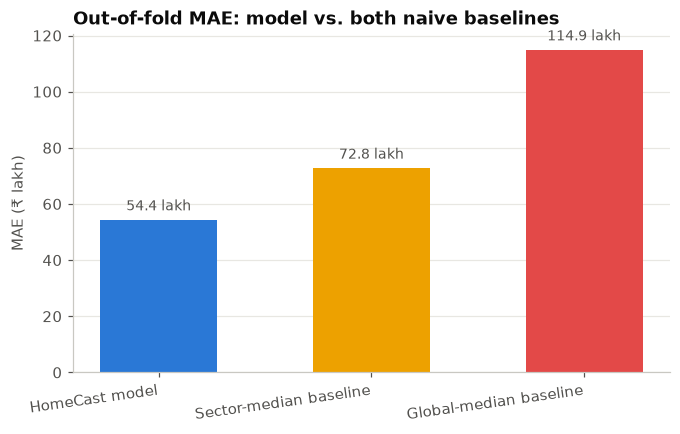

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
labels = results.index.tolist()
values = results["MAE (lakh)"].tolist()
colors = [PALETTE["blue"], PALETTE["yellow"], PALETTE["red"]]
bars = ax.bar(labels, values, color=colors, width=0.55)
ax.bar_label(bars, fmt="%.1f lakh", padding=4, fontsize=9, color="#52514e")
ax.set_title("Out-of-fold MAE: model vs. both naive baselines")
ax.set_ylabel("MAE (₹ lakh)")
ax.grid(axis="x", visible=False)
plt.setp(ax.get_xticklabels(), rotation=8, ha="right")
save_figure(fig, "baseline_comparison")
plt.show()

## Residuals, and the uncertainty band shipped with every prediction

`residuals_log` is `log(prediction) - log(actual)`, computed on the same
pooled out-of-fold predictions as the results table above — one value per
listing, from whichever fold held it out. Its 10th and 90th percentiles
become the multiplicative band `homecast.model.train_final` attaches to the
final model (`FittedModel.band`), and it's what `homecast.valuation.estimate`
uses to turn a single point estimate into the low–high range the app
actually shows a user.

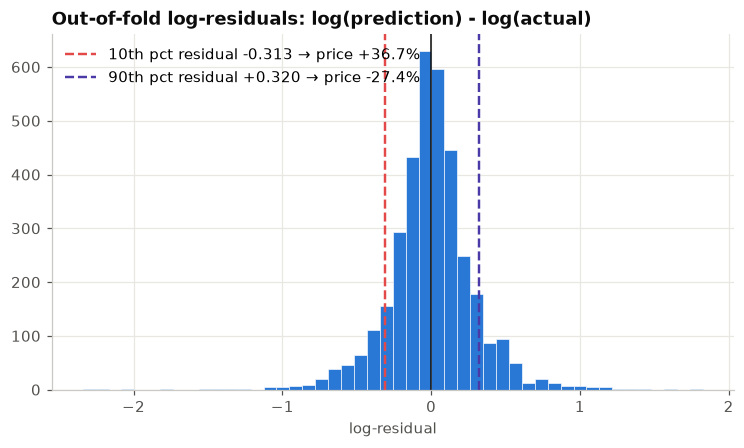

residual band in log space: -0.3128 to +0.3198
price band around a point estimate: -27.4% to +36.7%
skew(residuals) = -0.269


In [8]:
residuals_log = np.asarray(metrics["residuals_log"])
lo_log, hi_log = np.quantile(residuals_log, [0.10, 0.90])

# residual = log(prediction) - log(actual), so actual = prediction * exp(-residual).
# The sign flips when the residual band is turned into a price band: the 90th
# percentile residual (the model's biggest overestimates) sets the LOW end of
# the true price, and the 10th percentile residual sets the HIGH end.
lo_pct, hi_pct = np.exp(-hi_log) - 1, np.exp(-lo_log) - 1

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.hist(residuals_log, bins=48, color=PALETTE["blue"], edgecolor="white", linewidth=0.4)
ax.axvline(lo_log, color=PALETTE["red"], linewidth=1.6, linestyle="--",
           label=f"10th pct residual {lo_log:+.3f} → price {hi_pct:+.1%}")
ax.axvline(hi_log, color=PALETTE["violet"], linewidth=1.6, linestyle="--",
           label=f"90th pct residual {hi_log:+.3f} → price {lo_pct:+.1%}")
ax.axvline(0, color="#0b0b0b", linewidth=1.0)
ax.set_title("Out-of-fold log-residuals: log(prediction) - log(actual)")
ax.set_xlabel("log-residual")
ax.legend()
save_figure(fig, "residual_histogram")
plt.show()

print(f"residual band in log space: {lo_log:+.4f} to {hi_log:+.4f}")
print(f"price band around a point estimate: {lo_pct:+.1%} to {hi_pct:+.1%}")
print(f"skew(residuals) = {pd.Series(residuals_log).skew():.3f}")

In [9]:
price_quintile = pd.qcut(df["price"], 5, labels=["Q1 (cheapest)", "Q2", "Q3", "Q4", "Q5 (priciest)"])
mean_signed_residual = pd.Series(residuals_log, index=df.index).groupby(price_quintile, observed=True).mean()
print("mean signed log-residual by price quintile (positive = model overestimates, negative = model underestimates):")
print(mean_signed_residual.round(3))

k = int(len(residuals_log) * 0.10)
order = np.argsort(residuals_log)
biggest_overestimates = price_quintile.iloc[order[-k:]]
biggest_underestimates = price_quintile.iloc[order[:k]]
print(f"\nOf the 10% of listings the model overestimates by the widest margin, "
      f"{(biggest_overestimates == 'Q1 (cheapest)').mean():.0%} are in the cheapest quintile "
      f"(vs. a 20% base rate).")
print(f"Of the 10% it underestimates by the widest margin, "
      f"{(biggest_underestimates == 'Q5 (priciest)').mean():.0%} are in the priciest quintile "
      f"(vs. a 20% base rate).")

mean signed log-residual by price quintile (positive = model overestimates, negative = model underestimates):
price
Q1 (cheapest)    0.129
Q2               0.033
Q3              -0.001
Q4              -0.033
Q5 (priciest)   -0.129
dtype: float64

Of the 10% of listings the model overestimates by the widest margin, 42% are in the cheapest quintile (vs. a 20% base rate).
Of the 10% it underestimates by the widest margin, 44% are in the priciest quintile (vs. a 20% base rate).


For a typical prediction, this says the true price falls within roughly
-27% to +37% of the point estimate about 80% of the time (the 10th-90th
percentile band).

The percentage range looks lopsided, but the band itself is very nearly
symmetric in log space: the 10th percentile residual is -0.313 and the 90th
is +0.320, a difference of well under a hundredth of a log unit.
Exponentiating a symmetric log interval *always* produces a wider positive
percentage than negative one — `exp(+x) - 1 > |exp(-x) - 1|` for any x > 0 —
so the -27%/+37% shape is arithmetic, not a discovered property of the
model's errors. It would look the same for a perfectly symmetric error
distribution. (If anything the measured residual skew is slightly negative,
which points the other way; it is small enough not to read much into.)

Where the errors genuinely are lopsided is across the price range, and
splitting the residuals by price quintile shows it. Mean signed log-residual
runs monotonically from positive in the cheapest quintile to negative in the
priciest one: the model tends to *overestimate* the cheapest listings and
*underestimate* the most expensive ones. The listings it overestimates by
the widest margin are disproportionately the cheapest quintile, and the ones
it underestimates by the widest margin are disproportionately the priciest
quintile — both well above the 20% base rate a quintile would get by chance.
This foreshadows the error-by-quintile breakdown further below, where the
cheapest quintile turns out to have the highest mean absolute percentage
error of any of the five. It fits a right-skewed market: cheap listings are
pulled up toward the pack by the model's size/location features, while
luxury listings carry idiosyncratic premiums (brand, view, hyper-local
demand) the model has no feature for, so their true price tends to land
above what the model predicts. This band is exactly what ships in
`models/gurgaon/model.json` and is what a caller of
`homecast.valuation.estimate` gets back as `lo_cr`/`hi_cr` alongside the
point estimate.

## What the trained model actually leans on

`train_final` retrains on all 3,600 rows (no held-out fold — this is the
model that ships in `models/gurgaon/model.joblib`) using the same
`DEFAULT_PARAMS` and the fold-safe evaluation above to derive its metrics and
uncertainty band. `GradientBoostingRegressor.feature_importances_` gives the
(impurity-reduction-based) share of the model's splits attributable to each
feature, which is a useful sanity check on top of the accuracy numbers: if
the model were leaning on something that shouldn't matter, or ignoring
something that obviously should, that would be a sign the features or the
training data need another look before this is trusted with real
predictions.

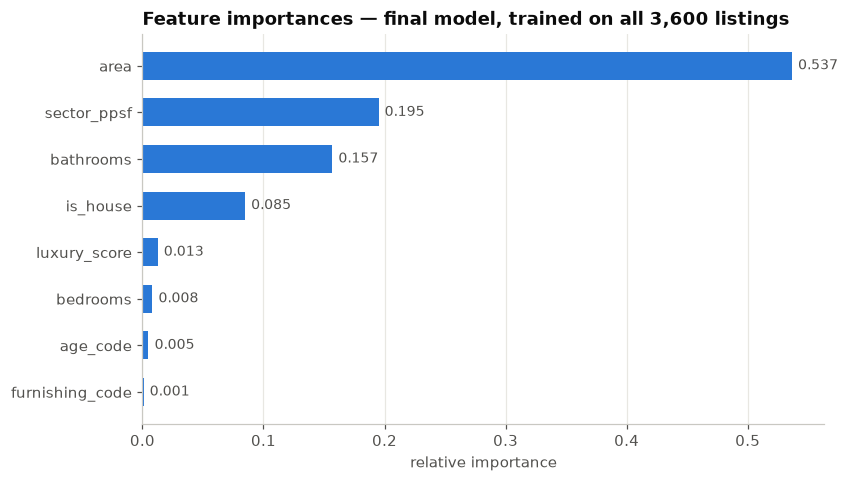

combined share of area + sector_ppsf: 73.2%


area               0.536540
sector_ppsf        0.195035
bathrooms          0.156843
is_house           0.084773
luxury_score       0.012620
bedrooms           0.008219
age_code           0.005013
furnishing_code    0.000957
dtype: float64

In [10]:
fitted = train_final(df)

importances = pd.Series(fitted.model.feature_importances_, index=FEATURE_COLUMNS).sort_values()

fig, ax = plt.subplots(figsize=(8, 4.6))
bars = ax.barh(importances.index, importances.values, color=PALETTE["blue"], height=0.6)
ax.bar_label(bars, fmt="%.3f", padding=4, fontsize=9, color="#52514e")
ax.set_title("Feature importances — final model, trained on all 3,600 listings")
ax.set_xlabel("relative importance")
ax.grid(axis="y", visible=False)
save_figure(fig, "feature_importances")
plt.show()

top2_share = importances.loc[["area", "sector_ppsf"]].sum()
print(f"combined share of area + sector_ppsf: {top2_share:.1%}")
importances.sort_values(ascending=False)

`area` alone accounts for over half the model's splits, and together with
`sector_ppsf` the two make up 73.2% of the total — just under three-quarters
— confirming that size and location (the only location signal available
here) are what mainly set the price band a listing falls into. `bathrooms`
is a distant but real third, ahead of `is_house`: a bathroom count higher
than what the area alone would suggest is a workable proxy for extra floors
or a higher specification, so the model leans on it as a secondary
size/quality signal. `is_house` captures what's left of the flat-vs-house
premium once area, location, and bathroom count are already accounted for.
Luxury score, age, bedroom count, and furnishing carry real but small
weight — they refine a price rather than set it, which is also the
intuitive ordering an experienced agent would use.

## Error by price quintile

A single MAPE number hides whether the model is uniformly reliable or
whether it's accurate for typical listings and shaky at the extremes. Using
the same out-of-fold residuals — `prediction = actual * exp(residual)`, so
`|prediction - actual| / actual = |exp(residual) - 1|` — split the listings
into five equal-sized price quintiles and look at the absolute percentage
error within each.

In [11]:
abs_pct_err = np.abs(np.exp(residuals_log) - 1) * 100
quintile = pd.qcut(df["price"], 5, labels=["Q1 (cheapest)", "Q2", "Q3", "Q4", "Q5 (priciest)"])

by_quintile = (
    pd.DataFrame({"price": df["price"], "quintile": quintile, "abs_pct_err": abs_pct_err})
    .groupby("quintile", observed=True)
    .agg(
        listings=("price", "size"),
        price_range_cr=("price", lambda s: f"{s.min():.2f}-{s.max():.2f}"),
        median_abs_pct_err=("abs_pct_err", "median"),
        mean_abs_pct_err=("abs_pct_err", "mean"),
    )
)
by_quintile.round(1)

,listings,price_range_cr,median_abs_pct_err,mean_abs_pct_err
quintile,,,,
Q1 (cheapest),743,0.07-0.85,17.7,27.6
Q2,740,0.86-1.30,13.3,18.4
Q3,681,1.31-1.82,11.2,17.5
Q4,719,1.83-3.35,11.7,20.6
Q5 (priciest),717,3.39-31.50,15.5,22.5


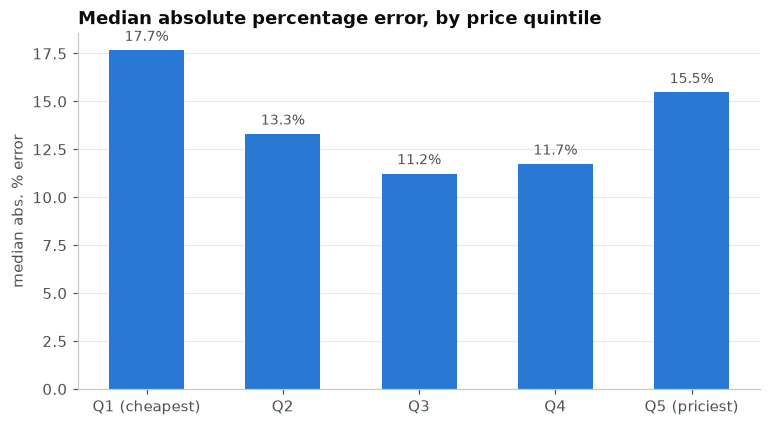

In [12]:
fig, ax = plt.subplots(figsize=(8, 4.2))
bars = ax.bar(by_quintile.index.astype(str), by_quintile["median_abs_pct_err"],
              color=PALETTE["blue"], width=0.55)
ax.bar_label(bars, fmt="%.1f%%", padding=4, fontsize=9, color="#52514e")
ax.set_title("Median absolute percentage error, by price quintile")
ax.set_ylabel("median abs. % error")
ax.grid(axis="x", visible=False)
save_figure(fig, "error_by_price_quintile")
plt.show()

Error is not flat across the price range. The model is most reliable in the
middle of the market — the price band with the most comparable listings to
learn from — and least reliable at the cheapest and most expensive quintiles,
where listings are sparser and more heterogeneous, so there's less for a
tree-based model to pattern-match against. That's the expected shape for a
comps-driven valuation model, not a defect specific to this one: any
approach, human or model, is more confident pricing a typical 3BHK than a
one-off luxury villa or an unusually cheap outlier.

## Limitations — what this model does not know

**Listing prices are asks, not transactions.** Every price in this dataset
is what a seller listed a property for, not what it sold for. Asking prices
run ahead of settled prices in most real-estate markets by some
negotiation margin, and that gap isn't observable from a listings feed
alone — there's no matched sold-price data to calibrate against. The model
is best read as "what sellers of comparable properties are currently asking
for," which is a genuinely useful number for pricing a new listing, but it
is not a prediction of the transaction price a buyer will ultimately pay.

**This is a single snapshot, not a time series.** The raw feed was collected
once. There's no date field, no way to tell a listing posted last week from
one that's been sitting for a year, and no way for the model to learn
seasonal patterns or price appreciation over time. A deployed valuation
built on this data is only as fresh as the crawl it was trained on, and
would need periodic retraining against newly collected listings to stay
accurate as the market moves.

**There's no latitude/longitude.** Location enters the model only through
`sector`, a coarse administrative label, encoded as that sector's median
price per sq. ft. Two listings in the same sector that differ only in exact
position — corner plot vs. interior, next to the metro vs. a 15-minute walk,
facing the park vs. facing another block — get the same location signal and
very similar predictions, even though an agent working the street would
price them differently.

**Extrapolation is guarded, but not eliminated.** `train_final` records the
observed min/max of `area`, `bedrooms`, `bathrooms`, and `luxury_score` from
the training data in `FittedModel.ranges`, and `homecast.valuation.estimate`
enforces every one of those bounds — plus the sector, property type,
furnishing, and age labels — raising rather than silently extrapolating or
falling back to a default:

In [13]:
print("Trained ranges:", fitted.ranges)

query = Query(sector="sector 65", property_type="flat", bedrooms=3, bathrooms=3,
              area=fitted.ranges["area"][1] + 5000, furnishing="semi-furnished", luxury_score=60)
try:
    estimate(fitted, query)
except ValueError as exc:
    print("\nRejected out-of-range query as expected:")
    print(" ", exc)

Trained ranges: {'area': [126.0, 15479.0], 'bedrooms': [1.0, 21.0], 'bathrooms': [1.0, 21.0], 'luxury_score': [0.0, 174.0]}

Rejected out-of-range query as expected:
  area 20479 outside supported range 126-15479 sq.ft.


Those guards cover each input on its own. A query that is technically inside
every recorded range but describes a *combination* the training data never
actually contained — a 1-BHK with a 100 luxury score, say — can still produce
a confident-looking number the model has no real basis for, because
`GradientBoostingRegressor` will always return *some* prediction for any
input inside its feature ranges. The uncertainty band widens that number
into a range rather than a false-precision point estimate, but it doesn't
replace judgment on whether a query actually resembles anything the model
was trained on.

None of this makes the model a transaction-price oracle, and it isn't meant
to be one. What it is: a valuation grounded in real listing data, evaluated
without leakage, benchmarked against the pricing rules it's meant to
replace, and shipped with an honest uncertainty range and a documented list
of where it should be trusted less.